# Trabalho Final — LLMs em Sistemas de Software

> **Instruções Gerais**
>
> Este trabalho deve ser entregue como um **Jupyter Notebook (.ipynb)** executado no **Google Colab**.
> Todas as células de código devem estar executadas e com os outputs visíveis no momento da entrega.
>
> - Documente seu raciocínio em células Markdown ao longo do notebook.
> - Use comentários no código para explicar decisões de implementação relevantes.
> - Certifique-se de que o notebook pode ser executado de ponta a ponta sem erros.
> - Variáveis sensíveis (API keys) devem ser carregadas via `google.colab.userdata` ou variáveis de ambiente — **nunca** expostas diretamente no código.

---
---
---

## Tema do Trabalho

Você irá construir um **sistema de perguntas e respostas baseado em RAG (Retrieval-Augmented Generation)** sobre uma base de documentos à sua escolha (exemplos: artigos técnicos, legislação, documentação de software, relatórios, etc.). O sistema deve ser construído com **LangChain**, explorar diferentes estratégias de **prompt engineering** e ser avaliado com métricas objetivas.


---
---
---


## Parte 1 — Prompt Engineering (3 pontos)

### Objetivo
Demonstrar domínio prático de diferentes técnicas de prompting e compreender como os hiperparâmetros do modelo afetam as respostas geradas.

### Tarefas

**1.1 — Comparação de estratégias de prompting**

Escolha uma tarefa de sua preferência (ex: classificação de texto, extração de informação, sumarização, geração de código) e implemente as três estratégias abaixo para a **mesma tarefa e o mesmo modelo**:

- **Zero-shot**: apenas a instrução, sem exemplos.
- **Few-shot**: instrução com 3 exemplos no prompt.
- **Chain-of-Thought (CoT)**: instrução que induz o modelo a raciocinar passo a passo antes de responder.

Para cada estratégia, execute ao menos **3 inputs diferentes** e registre as respostas.

**1.2 — Análise dos hiperparâmetros**

Usando a mesma tarefa do item 1.1, varie os seguintes parâmetros e registre o impacto observado nas respostas:

| Parâmetro     | Valores a testar         |
|---------------|--------------------------|
| `temperature` | 0.0 / 0.7 / 1.4          |
| `top_p`       | 0.5 / 0.9 / 1.0          |
| `max_tokens`  | Restritivo / Adequado / Amplo |

**1.3 — Discussão**

Em uma célula Markdown, responda:
- Qual estratégia apresentou os melhores resultados para a sua tarefa? Por quê?
- Como a variação de `temperature` impactou a consistência e criatividade das respostas?
- Quais limitações você identificou em cada abordagem?

### Critérios de Avaliação
- Implementação correta das três estratégias (1 pt)
- Experimento com hiperparâmetros documentado e com outputs visíveis (1 pt)
- Qualidade e profundidade da análise crítica (1 pt)


---
## Tarefas 1.1, 1.2, 1.3
*   Instalação de bibliotecas, funções e métodos para invocar os respectivos LLMs



In [1]:
!pip install -q -U \
    groq \
    langchain-groq \
    google-genai \
    langchain-community \
    langchain-text-splitters \
    faiss-cpu \
    pypdf \
    sentence-transformers \
    rouge-score==0.1.2
print('Bibliotecas instaladas!')

Bibliotecas instaladas!




> Os avisos do resolvedor do pip referem-se a pacotes pré-instalados do Colab (langchain umbrella, gradio, google-adk) que não são usados neste notebook; as bibliotecas efetivamente importadas estão consistentes e a execução roda de ponta a ponta.



In [2]:
import groq
import json
import time
import pandas as pd
import re
import os
import warnings
import matplotlib.pyplot as plt
import numpy as np

from google import genai as gemini
from google.genai import types as genai_types
from google.colab import userdata

from collections import defaultdict
from rouge_score import rouge_scorer

from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_community.document_loaders import DirectoryLoader, PyPDFLoader
from langchain_community.embeddings import HuggingFaceEmbeddings
from langchain_community.vectorstores import FAISS
from langchain_core.documents import Document
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser
from langchain_groq import ChatGroq

/tmp/ipykernel_137798/828370508.py:19: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.document_loaders import DirectoryLoader, PyPDFLoader


In [3]:
warnings.filterwarnings("ignore", category=DeprecationWarning)

In [4]:
def load_secrets():
    API_KEYS = ["GROQ_API_KEY", "GOOGLE_API_KEY"]
    tokens = {}
    for name in API_KEYS:
      try:
        value = userdata.get(name)
        print(f"API key configurada corretamente — {name}!")
        tokens[name] = value
      except Exception as e:
        print(f"Falha ao carregar key configure em secrets/Colab — {name}")
        tokens[name] = None
    return tokens[API_KEYS[0]], tokens[API_KEYS[1]]

# Plano A (1a opção)
def load_llm_provider_groq(api_groq):
  try:
    if api_groq:
      client = groq.Groq(api_key=api_groq)
      print("✅ Groq! LLM disponíveis:")
      EXCLUDE = ("whisper", "orpheus", "prompt-guard", "safeguard", "compound", "tts")
      for m in sorted(client.models.list().data, key=lambda x: x.id):
        if not any(t in m.id for t in EXCLUDE):
          print(f"    {m.id}")
      return client
  except Exception as e:
      print("❌ Groq: Falha ao instanciar LLM provider!")
  return None

# Plano B (2a opção, para o caso de rate limit!)
def load_llm_provider_google(api_google):
  try:
    if api_google:
      client = gemini.Client(api_key=api_google)
      print("✅ Gemini! LLM disponíveis:")
      EXCLUDE = ("image", "tts", "audio", "live", "embedding")
      for m in sorted(client.models.list(), key=lambda x: x.name):
        if "flash" in m.name and not any(t in m.name for t in EXCLUDE) and "generateContent" in m.supported_actions:
            print(f"    {m.name}")
      return client
  except Exception as e:
      print("❌ Gemini: Falha ao instancar LLM provider")
  return None

def pretty(object):
  print(json.dumps(object, indent=2, ensure_ascii=False))

*   Carregar `API Keys`, respectivos `LLM providers` e verificar modelos disponíveis

In [5]:
def invoke_groq(client, prompt, model, system, temperature, max_tokens, top_p):
    if not client:
        print("❌ Groq: client não disponível!")
        return None, 0.0
    try:
      start = time.time()
      response = client.chat.completions.create(
          model=model,
          temperature=temperature,
          max_tokens=max_tokens,
          top_p=top_p,
          messages=[
              {"role": "system", "content": system},
              {"role": "user",   "content": prompt}
          ],
          response_format={"type": "json_object"}
      )
      time_ms = (time.time() - start) * 1000
      return json.loads(response.choices[0].message.content), round(time_ms, 1)
    except Exception as e:
      time_ms = (time.time() - start) * 1000
      print(f"❌ Groq: Falha ao gerar resposta — {e}")
      return None, round(time_ms, 1)

def invoke_gemini(client, prompt, model, system, temperature, max_tokens, top_p):
    if not client:
        print("❌ Gemini: client não disponível!")
        return None, 0.0
    start = time.time()
    config = genai_types.GenerateContentConfig(
        temperature=temperature,
        max_output_tokens=max_tokens,
        top_p=top_p,
        system_instruction=system,
        response_mime_type="application/json"
    )
    try:
      response = client.models.generate_content(
          model=model,
          contents=prompt,
          config=config
      )
      time_ms = (time.time() - start) * 1000
      return json.loads(response.text), round(time_ms, 1)
    except Exception as e:
      time_ms = (time.time() - start) * 1000
      print(f"❌ Gemini: Falha ao gerar resposta — {e}")
      return None, round(time_ms, 1)

In [6]:
api_groq, api_google = load_secrets()
print(15*'-')
gqc = load_llm_provider_groq(api_groq)
print(15*'-')
gic = load_llm_provider_google(api_google)
print(15*'-')
print('    flash-lite ... +leve, +barato, baixa latência (alto volume)')
print('    flash ........ melhor qualidade de resposta, rápido e barato, raciocínio, custo-benefício')

API key configurada corretamente — GROQ_API_KEY!
API key configurada corretamente — GOOGLE_API_KEY!
---------------
✅ Groq! LLM disponíveis:
    allam-2-7b
    llama-3.1-8b-instant
    llama-3.3-70b-versatile
    meta-llama/llama-4-scout-17b-16e-instruct
    openai/gpt-oss-120b
    openai/gpt-oss-20b
    qwen/qwen3-32b
    qwen/qwen3.6-27b
---------------
✅ Gemini! LLM disponíveis:
    models/gemini-2.0-flash
    models/gemini-2.0-flash-001
    models/gemini-2.0-flash-lite
    models/gemini-2.0-flash-lite-001
    models/gemini-2.5-flash
    models/gemini-2.5-flash-lite
    models/gemini-3-flash-preview
    models/gemini-3.1-flash-lite
    models/gemini-3.1-flash-lite-preview
    models/gemini-3.5-flash
    models/gemini-flash-latest
    models/gemini-flash-lite-latest
---------------
    flash-lite ... +leve, +barato, baixa latência (alto volume)
    flash ........ melhor qualidade de resposta, rápido e barato, raciocínio, custo-benefício


*   Criação de dataset para execução dos experimentos

In [7]:
DATASET = [
  # Positivo ---------
  {"texto": "Adorei! Material de ótima qualidade e o atendimento foi impecável.", "sentimento": "positivo"},
  {"texto": "Entrega rápida, recomendo a loja a todos os meus amigos.", "sentimento": "positivo"},
  {"texto": "Superou minhas expectativas, vale cada centavo. Voltarei a comprar!", "sentimento": "positivo"},
  {"texto": "Atendimento nota mil, resolveram meu problema em minutos. Recomendo demais!", "sentimento": "positivo"},
  {"texto": "Melhor compra que fiz no ano, qualidade impecável e entrega relâmpago!", "sentimento": "positivo"},
  # Neutro -----------
  {"texto": "Recebi o item corretamente; experiência comum, sem pontos altos ou baixos.", "sentimento": "neutro"},
  {"texto": "O produto é razoável, faz o que diz, mas nada que me surpreenda.", "sentimento": "neutro"},
  {"texto": "Veio na data certa, mas a embalagem estava amassada. Atende o básico.", "sentimento": "neutro"},
  {"texto": "Cumpre o que promete, nada de mais. É um produto mediano.", "sentimento": "neutro"},
  {"texto": "Funciona, porém o preço está um pouco alto para o que oferece.", "sentimento": "neutro"},
  # Negativo ---------
  {"texto": "Péssima experiência: o produto veio com defeito e o suporte nunca respondeu.", "sentimento": "negativo"},
  {"texto": "Não comprem! Propaganda enganosa, o item é totalmente diferente das fotos.", "sentimento": "negativo"},
  {"texto": "Demorou um mês para chegar e ainda veio o modelo errado. Decepcionante.", "sentimento": "negativo"},
  {"texto": "Veio riscado e o suporte ignorou meus e-mails. Nunca mais compro aqui.", "sentimento": "negativo"},
  {"texto": "Parou de funcionar em dois dias e a garantia não cobriu. Lixo total.", "sentimento": "negativo"},
]

*   Definição de `SYSTEM`

In [8]:
SYSTEM = """
  Você é um assistente especializado em análise de sentimentos.

  Classifique o texto do usuário, conforme instruções abaixo:
  - Responda SEMPRE em PT-BR.
  - Responda SEMPRE em formato JSON válido, sem qualquer texto adicional.
  - Respeite o limite máximo de tokens de saída solicitado.
  - O campo "sentimento" deve ser obrigatoriamente um destes valores: "positivo", "neutro" ou "negativo".

  Schema obrigatório da resposta:
  {
    "sentimento": "positivo | neutro | negativo",
    "justificativa": "explicação curta (1 frase) do motivo da classificação"
  }
"""

SYSTEM_COT = """
  Você é um assistente especializado em análise de sentimentos.

  Classifique o texto do usuário, RACIOCINANDO passo a passo antes de decidir e conforme instruções abaixo:
  - Responda SEMPRE em PT-BR.
  - Responda SEMPRE em formato JSON válido, sem qualquer texto adicional.
  - Respeite o limite máximo de tokens de saída solicitado.
  - O campo "sentimento" deve ser obrigatoriamente um destes valores: "positivo", "neutro" ou "negativo".

  Schema obrigatório da resposta: (nesta ORDEM)
  {
    "raciocinio": "análise do texto (passo a passo)",
    "sentimento": "positivo | neutro | negativo",
    "justificativa": "explicação curta (1 frase) do motivo da classificação"
  }
"""

*   Definição dos prompts

In [9]:
def prompt(text):
  return f'''
  Classifique o seguinte texto: "{text}"
  '''

def prompt_few_shot(text):
  return f'''
  Classifique o seguinte texto: "{text}"

  De acordo com estas referências:

  texto: "Produto excelente, chegou antes do prazo e funciona perfeitamente!"
  sentimento: positivo

  texto: "O tamanho é exatamente o anunciado. Pedido entregue conforme o combinado."
  sentimento: neutro

  texto: "Quebrou na primeira semana de uso. Dinheiro jogado fora."
  sentimento: negativo
  '''

In [10]:
GQC_MODEL  = "llama-3.3-70b-versatile"
GIC_MODEL  = "models/gemini-3.1-flash-lite"

*   Experimentos (1.1 + 1.2)

In [11]:
STRATEGY = {
  "zero-shot": (SYSTEM, prompt),
  "few-shot":  (SYSTEM, prompt_few_shot),
  "cot":       (SYSTEM_COT, prompt)
}

TURNS = [
  {"temperature": 0.0, "max_tokens":  50},
  {"temperature": 0.0, "max_tokens": 256},
  {"temperature": 0.0, "max_tokens": 1024},
  {"temperature": 1.0, "max_tokens":  50},
  {"temperature": 1.0, "max_tokens": 256},
  {"temperature": 1.0, "max_tokens": 1024}
]

INPUT = [
  DATASET[0], # positivo
  DATASET[5], # neutro
  DATASET[10] # negativo
]

results = []
for name, (system, build_prompt) in STRATEGY.items():
  print("-" * 15)
  print(name)
  print("-" * 15)
  print('')
  for turn in TURNS:
    for item in INPUT:
      resp, ms = invoke_groq(
        gqc, build_prompt(item["texto"]), GQC_MODEL, system,
        turn["temperature"], turn["max_tokens"], top_p=1.0
      )
      print(f'temperature ..... {turn['temperature']}')
      print(f'max_tokens ...... {turn['max_tokens']}')
      print(f'texto ........... {item["texto"]}')
      print(f'esperado ........ {item["sentimento"]}')
      print(f'previsto ........ {resp["sentimento"] if resp else '(truncado)'}')
      print(f'justificativa ... {resp["justificativa"] if resp else None}')
      print(f'raciocinio ...... {resp.get("raciocinio", "N/A") if resp else "N/A"}')
      print(f'tempo (ms) ...... {ms}')
      print('')
      results.append({
          'strategy'    : name,
          'temperature' : turn['temperature'],
          'max_tokens'  : turn['max_tokens'],
          'top_p'       : 1.0,
          'ok'          : bool(resp) and item["sentimento"] == resp["sentimento"],
          'ms'          : ms,
          'just_len'    : len(resp["justificativa"]) if resp else None
      })
      # RPM / rate limit...
      time.sleep(0.3)

---------------
zero-shot
---------------

temperature ..... 0.0
max_tokens ...... 50
texto ........... Adorei! Material de ótima qualidade e o atendimento foi impecável.
esperado ........ positivo
previsto ........ positivo
justificativa ... O texto expressa satisfação com o material e o atendimento.
raciocinio ...... N/A
tempo (ms) ...... 446.5

temperature ..... 0.0
max_tokens ...... 50
texto ........... Recebi o item corretamente; experiência comum, sem pontos altos ou baixos.
esperado ........ neutro
previsto ........ neutro
justificativa ... O texto descreve uma experiência comum, sem pontos altos ou baixos, indicando uma avaliação neutra.
raciocinio ...... N/A
tempo (ms) ...... 458.2

temperature ..... 0.0
max_tokens ...... 50
texto ........... Péssima experiência: o produto veio com defeito e o suporte nunca respondeu.
esperado ........ negativo
previsto ........ negativo
justificativa ... O texto expressa insatisfação com o produto e o suporte.
raciocinio ...... N/A
tempo (ms)

*   Resultados (1.3)

In [12]:
df12 = pd.DataFrame(results)
df12

,strategy,temperature,max_tokens,top_p,ok,ms,just_len
0,zero-shot,0.0,50,1.0,True,446.5,59.0
1,zero-shot,0.0,50,1.0,True,458.2,99.0
2,zero-shot,0.0,50,1.0,True,555.1,56.0
3,zero-shot,0.0,256,1.0,True,311.5,59.0
4,zero-shot,0.0,256,1.0,True,518.6,99.0
5,zero-shot,0.0,256,1.0,True,412.4,56.0
6,zero-shot,0.0,1024,1.0,True,478.5,59.0
7,zero-shot,0.0,1024,1.0,True,493.6,99.0
8,zero-shot,0.0,1024,1.0,True,409.2,56.0
9,zero-shot,1.0,50,1.0,True,599.2,108.0


In [13]:
df12.groupby('strategy')['ok'].value_counts().to_frame().reset_index()

,strategy,ok,count
0,cot,True,12
1,cot,False,6
2,few-shot,True,18
3,zero-shot,True,18


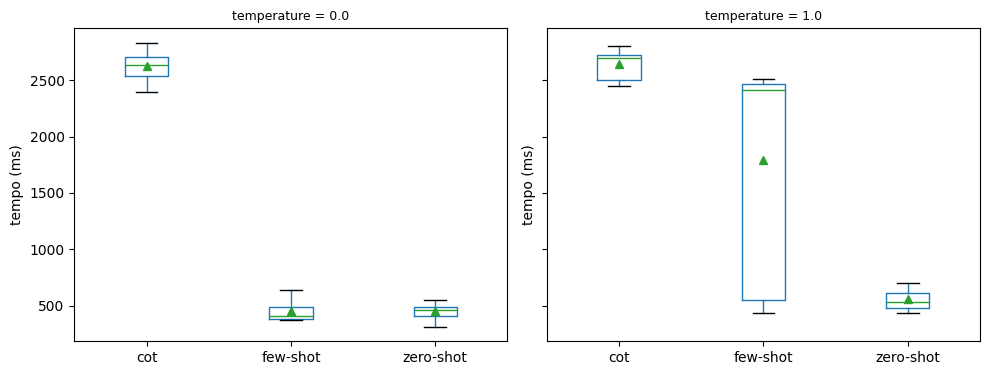

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)

for ax, temp in zip(axes, [0.0, 1.0]):
    sub = df12[df12.temperature == temp]
    sub.boxplot(column="ms", by="strategy", grid=False, ax=ax, showmeans=True)
    ax.set_title(f"temperature = {temp}", fontsize=9)
    ax.set_xlabel("")
    ax.set_ylabel("tempo (ms)")

fig.suptitle("")
plt.tight_layout()
plt.show()

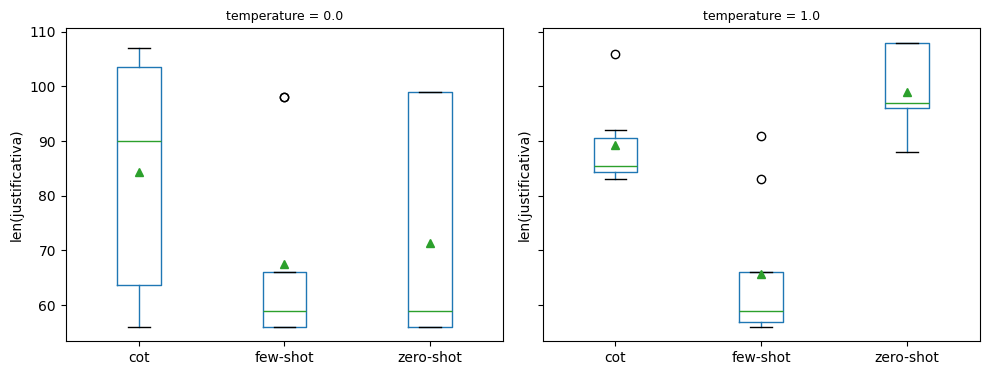

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)

for ax, temp in zip(axes, [0.0, 1.0]):
    sub = df12[df12.temperature == temp]
    sub.boxplot(column="just_len", by="strategy", grid=False, ax=ax, showmeans=True)
    ax.set_title(f"temperature = {temp}", fontsize=9)
    ax.set_xlabel("")
    ax.set_ylabel("len(justificativa)")

fig.suptitle("")
plt.tight_layout()
plt.show()

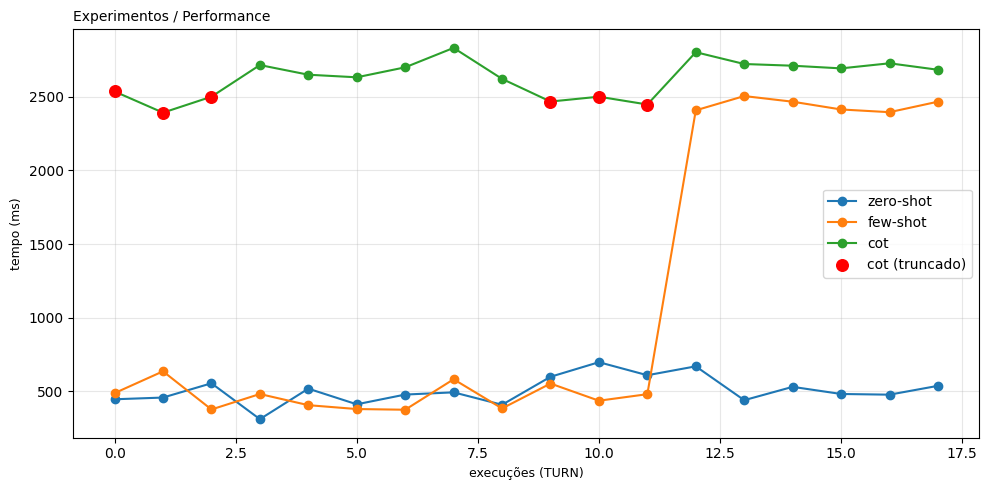

In [16]:
plt.figure(figsize=(10, 5))
for name in df12["strategy"].unique():
    sub = df12[df12["strategy"] == name].reset_index(drop=True)
    plt.plot(sub.index, sub["ms"], marker="o", label=name)
    error = sub[~sub["ok"]]
    plt.scatter(error.index, error["ms"], color="red", zorder=2,
                s=70, label=f"{name} (truncado)" if not error.empty else None)

plt.title("Experimentos / Performance", loc="left", fontsize=10)
plt.xlabel("execuções (TURN)", fontsize=9)
plt.ylabel("tempo (ms)", fontsize=9)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**Discussão:**
* Experimentos foram realizados explorando 3 estratégias x 6 turnos (hiperparâmetros) x 3 inputs = 54 execuções.
* Os resultados foram consolidados no `df12` e demonstrados no gráfico: Experimentos / Performance, acima.

**Qual estratégia apresentou os melhores resultados? Por quê?**
* Zero-shot! Como todas as estratégias apresentaram 100% de acurácia (nos casos em que completaram a resposta), o desempate foi custo e robustez:
  * Zero-shot: curva mais baixa do gráfico (~310–700 ms), estável e sem falha.
  * Few-shot: mesma acurácia, porém custa mais tokens (exemplos no prompt) e como mostra o gráfico, apresenta um salto para ~2.4 s nos testes com temperature=1.0 e max_tokens ≥ 256, degradando a latência e sem ganhos efetivos de qualidade.
  * CoT: em virtude da solicitação de raciocinar antes de responder ao usuário, sua latência sempre se manteve no topo (~2.6 s = ~5x Zero-shot), além de demonstrar sua limitação para `max_tokens` restritivos (falhas/parser JSON), pois exige uma quantidade maior de tokens para compor a resposta

**Como a variação de `temperature` impactou a consistência e criatividade das respostas?**
* Consistência: rótulo (classificação) inalterada - todas as predições se mantiveram corretas, independemente da temperatura.
* Criatividade (texto, justificativa): a mediana de `len(justificativa)` aumentou de temp=0.0 para temp=1.0 — Zero-Shot (~ 59 → ~ 97, como esperado), Few-Shot (~ 59 → ~ 59, os exemplos estabilizaram o tamanho da justificativa) e CoT, que já parte de um patamar ~ 30 caracteres acima (~ 87) por incluir o raciocínio. Esse aumento da mediana (com mais temperatura) é esperado: respostas + elaboradas/variadas.
* Efeito colateral: temperature=`1.0` elevou e degradou a latência (outliers e IQR do Few-Shot, veja boxplot acima).

**Quais limitações você identificou em cada abordagem?**
* Zero-Shot: depende totalmente da clareza da instrução
* Few-Shot: consome mais tokens e há risco dos exemplos, caso não representativos, adicionarem um viés na interpretação e resposta pelo LLM. E dependendo da tarefa, o conhecimento `pre-trained` via Zero-Shot talvez já seja suficiente para atingir os critérios de aceitação (+ barata e rápida)
* CoT: Mais caro e lento (curvas superiores dos gráficos); frágil a max_tokens restritivo - com 50 tokens o JSON é cortado no raciocinio e o parsing falha (pontos vermelhos) dos gráficos. Mais vantajoso talvez para tarefas mais complexas que exigem um raciocínio multi-passo.

## Parte 2 — Construção do Pipeline RAG com LangChain (3,5 pontos)

### Objetivo
Construir um pipeline RAG completo e funcional utilizando LangChain, integrando carregamento de documentos, chunking, embeddings, banco vetorial e recuperação.

### Tarefas

**2.1 — Preparação da base de dados**

- Escolha uma coleção de documentos (mínimo de **3 arquivos** em PDF, TXT ou CSV).
- Carregue os documentos utilizando os **Document Loaders** do LangChain.
- Aplique **uma estratégia de chunking** (ex: `RecursiveCharacterTextSplitter` com tamanhos distintos, ou `CharacterTextSplitter` ou chunking por parágrafo) e justifique a escolha final.

**2.2 — Indexação vetorial**

- Gere embeddings com um modelo à sua escolha (ex: OpenAI `text-embedding-ada-002`, HuggingFace `sentence-transformers`, etc.).
- Indexe os chunks em um banco vetorial (FAISS, Chroma ou Pinecone).
- Demonstre uma busca de similaridade direta no banco vetorial com ao menos **2 queries de teste**, exibindo os chunks recuperados.

**2.3 — Pipeline de geração**

- Monte uma chain de RAG com LangChain (`RetrievalQA` ou `ConversationalRetrievalChain`) que:
  - Recupere os `top-k` chunks mais relevantes (experimente ao menos dois valores de `k`).
  - Injete o contexto recuperado em um prompt estruturado.
  - Gere a resposta final com o LLM de sua escolha.
- Execute ao menos **3 perguntas** sobre a sua base de documentos e exiba as respostas com os respectivos trechos de contexto utilizados.

### Critérios de Avaliação
- Carregamento, chunking e indexação corretos e justificados (1,5 pt)
- Pipeline RAG funcional com contexto injetado corretamente (1,5 pt)
- Diversidade de queries testadas e clareza nos outputs (0,5 pt)


## Parte 2 - Construção do Pipeline RAG com LangChain

## Tarefa 2.1: Preparação da base de dados

Instalamos todas as bibliotecas necessárias para o pipeline RAG.

**[Werner]** Migrado para o começo do notebook.

### 2.1.1 Configuração da API Key da Groq

Carregamos a chave da API Groq de forma segura.

**[Werner]** Comentado para reaproveitar o código usado na Parte 1 (acima)

In [17]:
# import os, json, time
# from groq import Groq

# # Carrega a chave de forma segura a partir dos Secrets do Colab
# # Se não estiver no Colab, usa variável de ambiente como fallback
# try:
#     from google.colab import userdata
#     GROQ_API_KEY = userdata.get("GROQ_API_KEY")
# except Exception:
#     GROQ_API_KEY = os.environ.get("GROQ_API_KEY", "SUA_CHAVE_AQUI")

# # Configuramos a chave como variável de ambiente (necessária para langchain-groq)
# os.environ["GROQ_API_KEY"] = GROQ_API_KEY

# # Inicializamos o cliente Groq (útil para chamadas diretas, ex: Parte 3)
# client = Groq(api_key=GROQ_API_KEY)

# # Definimos os modelos que serão utilizados
# MODEL_RAG = "llama-3.1-8b-instant"      # Rápido, para gerar respostas no RAG

# print("✅ Configuração Groq OK!")
# print(f"   Model : {MODEL_RAG}")

In [18]:
GQC_MODEL  = "llama-3.1-8b-instant"

###  2.1.2 Preparação da base de dados

Descrição:

Nesta etapa realizamos três operações fundamentais:



* CRIAÇÃO DOS DOCUMENTOS DE EXEMPLO: Como o enunciado pede no mínimo 3 arquivos, criamos 3 documentos .txt sobre o tema "Inteligência Artificial" como exemplo. Na prática, você pode substituir por seus próprios PDFs, TXTs ou CSVs.
* CARREGAMENTO COM DOCUMENT LOADERS: Usamos DirectoryLoader + TextLoader do LangChain para carregar todos os arquivos .txt de uma pasta de forma automática.
* CHUNKING (DIVISÃO EM TRECHOS): Usamos RecursiveCharacterTextSplitter, que é a estratégia que divide primeiro por parágrafos (\n\n), depois por frases (\n), e por último por caracteres individuais.

### 2.1.3 Criação dos documentos de exemplo

**[Werner]** Comentado: ao invés dos exemplos, gostaria de explorar RAG sobre surveys do Kaggle (abaixo)

In [19]:
# # Criamos uma pasta "documentos" e salvamos 3 arquivos de texto sobre IA.

# os.makedirs("documentos", exist_ok=True)

# # Documento 1: História da IA
# doc1 = """Inteligência Artificial: Uma Breve História

# A Inteligência Artificial (IA) é um campo da ciência da computação que busca
# criar sistemas capazes de realizar tarefas que normalmente requerem inteligência
# humana. O termo foi cunhado por John McCarthy em 1956, durante a conferência de
# Dartmouth, considerada o marco fundador da área.

# Nas décadas de 1960 e 1970, os pesquisadores desenvolveram sistemas especialistas,
# que eram programas baseados em regras lógicas para resolver problemas específicos.
# No entanto, essas abordagens tinham limitações significativas na generalização.

# O chamado "inverno da IA" ocorreu nos anos 1980 e início dos anos 1990, quando o
# financiamento e o interesse na área diminuíram drasticamente devido às expectativas
# não cumpridas. A recuperação veio com o avanço do poder computacional e o
# surgimento de técnicas de aprendizado de máquina.

# A partir de 2010, o deep learning revolucionou a IA, permitindo avanços
# significativos em reconhecimento de imagens, processamento de linguagem natural
# e jogos. Marcos importantes incluem a vitória do AlphaGo sobre o campeão mundial
# de Go em 2016 e o lançamento do GPT-3 em 2020.
# """

# # Documento 2: Tipos de IA
# doc2 = """Tipos de Inteligência Artificial

# A IA pode ser classificada em diferentes categorias com base em suas capacidades:

# 1. IA Estreita (Narrow AI ou ANI):
# É o tipo de IA que existe atualmente. São sistemas projetados para realizar
# tarefas específicas, como reconhecimento facial, tradução automática ou
# recomendação de conteúdo. Exemplos incluem Siri, Alexa e sistemas de GPS.
# A ANI não possui consciência nem compreensão real do que faz.

# 2. IA Geral (AGI - Artificial General Intelligence):
# É uma IA hipotética que teria capacidades cognitivas equivalentes às humanas,
# podendo aprender e realizar qualquer tarefa intelectual que um ser humano pode.
# Ainda não foi alcançada e é tema de intenso debate na comunidade científica.

# 3. Superinteligência Artificial (ASI):
# É um conceito teórico de uma IA que superaria a inteligência humana em todos
# os aspectos, incluindo criatividade, resolução de problemas e habilidades
# sociais. Pesquisadores como Nick Bostrom alertam para os riscos potenciais.

# Machine Learning (Aprendizado de Máquina):
# É um subcampo da IA que permite que sistemas aprendam a partir de dados sem
# serem explicitamente programados. Os três paradigmas principais são:
# - Aprendizado Supervisionado: treina com dados rotulados
# - Aprendizado Não Supervisionado: encontra padrões em dados sem rótulos
# - Aprendizado por Reforço: aprende através de tentativa e erro com recompensas
# """

# # Documento 3: Aplicações e ética
# doc3 = """Aplicações e Ética da Inteligência Artificial

# Aplicações Práticas da IA:

# Saúde: A IA é utilizada para diagnóstico médico assistido, análise de imagens
# de exames (raio-X, ressonância magnética), descoberta de novos medicamentos
# e monitoramento remoto de pacientes. Modelos de deep learning conseguem
# detectar certos tipos de câncer com precisão comparável à de médicos especialistas.

# Educação: Sistemas de tutoria inteligente adaptam o conteúdo ao ritmo de
# aprendizado de cada aluno. Plataformas como Duolingo usam IA para personalizar
# exercícios e otimizar a retenção de conhecimento.

# Transporte: Veículos autônomos utilizam múltiplos sensores e algoritmos de IA
# para navegar. Empresas como Tesla, Waymo e Cruise investem bilhões nessa tecnologia.
# A IA também otimiza rotas logísticas e gestão de tráfego urbano.

# Finanças: Algoritmos de IA detectam fraudes em transações bancárias, fazem
# previsões de mercado e automatizam processos de análise de crédito.

# Questões Éticas:

# Viés Algorítmico: Modelos de IA podem perpetuar e amplificar preconceitos
# presentes nos dados de treinamento, levando a decisões discriminatórias em
# áreas como contratação, crédito e justiça criminal.

# Privacidade: O uso massivo de dados pessoais para treinar modelos de IA
# levanta preocupações sobre vigilância e uso indevido de informações.

# Impacto no Emprego: A automação impulsionada pela IA pode substituir empregos
# em diversos setores, exigindo políticas de requalificação profissional.

# Regulamentação: A União Europeia propôs o AI Act, uma das primeiras legislações
# abrangentes para regular o desenvolvimento e uso de sistemas de IA, classificando
# aplicações por nível de risco.
# """

# # Salvamos cada documento em um arquivo separado
# with open("documentos/historia_ia.txt", "w", encoding="utf-8") as f:
#     f.write(doc1)

# with open("documentos/tipos_ia.txt", "w", encoding="utf-8") as f:
#     f.write(doc2)

# with open("documentos/aplicacoes_etica_ia.txt", "w", encoding="utf-8") as f:
#     f.write(doc3)

# print("3 documentos criados na pasta 'documentos/':")
# for arquivo in os.listdir("documentos"):
#     print(f"    {arquivo}")

In [20]:
os.makedirs("documentos", exist_ok=True)

DOCS = {
    "kaggle_survey_2022.pdf": "https://storage.googleapis.com/kaggle-media/surveys/Kaggle State of Machine Learning and Data Science Report 2022.pdf",
    "kaggle_survey_2021.pdf": "https://storage.googleapis.com/kaggle-media/surveys/Kaggle's State of Machine Learning and Data Science 2021.pdf",
    "kaggle_survey_2020.pdf": "https://storage.googleapis.com/kaggle-media/surveys/Kaggle State of Machine Learning and Data Science 2020.pdf",
}

for name, url in DOCS.items():
    target = f"documentos/{name}"
    !wget -q -O "{target}" "{url}"
    print(f"  {name} — {os.path.getsize(target)//1024} KB")

  kaggle_survey_2022.pdf — 2492 KB
  kaggle_survey_2021.pdf — 4226 KB
  kaggle_survey_2020.pdf — 14377 KB


### 2.1.4 Carregamento dos documentos com Document Loaders

O DirectoryLoader percorre uma pasta e carrega todos os arquivos que correspondem ao padrão glob (neste caso, *.txt). Cada arquivo é convertido em um objeto Document do LangChain, que contém o texto (page_content) e metadados (metadata).

**[Werner]** Comentado para ler PDF ao invés de TXT, abaixo

In [21]:
# from langchain_community.document_loaders import DirectoryLoader, TextLoader

# # Configuramos o loader para ler todos os arquivos .txt da pasta "documentos"
# # O parâmetro loader_kwargs define a codificação UTF-8 para suportar acentos
# loader = DirectoryLoader(
#     path="documentos",            # Pasta onde estão os documentos
#     glob="**/*.txt",              # Padrão: todos os .txt, incluindo subpastas
#     loader_cls=TextLoader,        # Classe de carregamento para arquivos de texto
#     loader_kwargs={"encoding": "utf-8"}  # Codificação para caracteres especiais
# )

# # Executamos o carregamento
# documentos = loader.load()

# print(f"  Total de documentos carregados: {len(documentos)}")
# print()

# # Exibimos informações sobre cada documento carregado
# for i, doc in enumerate(documentos):
#     print(f"   Documento {i+1}:")
#     print(f"   Arquivo: {doc.metadata['source']}")
#     print(f"   Tamanho: {len(doc.page_content)} caracteres")
#     print(f"   Prévia:  {doc.page_content[:100]}...")
#     print()

In [22]:
# Carregar todos os PDFs da pasta "documentos" com PyPDFLoader
loader = DirectoryLoader(
    path="documentos",       # Pasta onde estão os PDFs baixados da Kaggle
    glob="**/*.pdf",         # Padrão: todos os .pdf
    loader_cls=PyPDFLoader,  # Loader específico para PDF (usa pypdf)
)
print('Step 1 | Documentos carregados!')

# Executar loading (cada página -> um Document)
docs = loader.load()
print('Step 2 ! Páginas carregadas!')

# Agregar todas as páginas/Document por PDF (source)
by_source = defaultdict(lambda: {"pages": 0, "chars": 0})
for page in docs:
    source = page.metadata["source"]
    by_source[source]["pages"] += 1
    by_source[source]["chars"] += len(page.page_content)
print('Step 3 | Páginas agregadas por arquivo!')

# Resumo por arquivo (páginas + texto realmente extraído)
for source, info in by_source.items():
    print('')
    print(f"{source}")
    print(f"páginas .......... {info['pages']}")
    print(f"texto extraído ... {info['chars']} caracteres")

Step 1 | Documentos carregados!
Step 2 ! Páginas carregadas!
Step 3 | Páginas agregadas por arquivo!

documentos/kaggle_survey_2021.pdf
páginas .......... 45
texto extraído ... 13529 caracteres

documentos/kaggle_survey_2020.pdf
páginas .......... 30
texto extraído ... 21378 caracteres

documentos/kaggle_survey_2022.pdf
páginas .......... 27
texto extraído ... 3416 caracteres


### 2.1.5 Chunking (Divisão em trechos menores)

In [23]:
# Configuramos o text splitter com os parâmetros escolhidos
text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=500,       # Tamanho máximo de cada chunk (em caracteres)
    chunk_overlap=50,     # Sobreposição entre chunks consecutivos
    length_function=len,  # Função para medir o tamanho (contagem de caracteres)
    separators=[          # Hierarquia de separadores (do mais preferido ao menos)
        "\n\n",           # Primeiro tenta: separar por parágrafos
        "\n",             # Depois: por quebras de linha
        " ",              # Depois: por espaços (entre palavras)
        ""                # Último recurso: caractere por caractere
    ]
)

In [24]:
# Aplicamos o chunking em todos os documentos carregados
chunks = text_splitter.split_documents(docs)

print(f"Chunking concluído!")
print(f"   Documentos originais: {len(docs)}")
print(f"   Chunks gerados: {len(chunks)}")
print(f"   Tamanho configurado: 500 caracteres (com 50 de overlap)")
print()

# Exibimos os primeiros 5 chunks para verificação
print("=" * 70)
print("PRÉVIA DOS PRIMEIROS 5 CHUNKS:")
print("=" * 70)
for i, chunk in enumerate(chunks[:5]):
    print(f"\nChunk {i+1} (fonte: {chunk.metadata['source']}):")
    print(f"   Tamanho: {len(chunk.page_content)} caracteres")
    print(f"   Conteúdo:\n   {chunk.page_content[:200]}...")
    print("-" * 70)

Chunking concluído!
   Documentos originais: 102
   Chunks gerados: 136
   Tamanho configurado: 500 caracteres (com 50 de overlap)

PRÉVIA DOS PRIMEIROS 5 CHUNKS:

Chunk 1 (fonte: documentos/kaggle_survey_2021.pdf):
   Tamanho: 143 caracteres
   Conteúdo:
   State of Machine Learning
and Data Science 2021
 Insights from Kaggle’s annual user survey focused
on working data scientists.
October 14, 2021...
----------------------------------------------------------------------

Chunk 2 (fonte: documentos/kaggle_survey_2021.pdf):
   Tamanho: 218 caracteres
   Conteúdo:
   Kaggle   |   State of ML & Data Science 2021  
01 Data Scientist Profile
Table of Contents
02 Education
03 Data Science & Machine Learning Experience
04 Employment
05 Technology
Overview & Report Meth...
----------------------------------------------------------------------

Chunk 3 (fonte: documentos/kaggle_survey_2021.pdf):
   Tamanho: 101 caracteres
   Conteúdo:
   Kaggle   |   State of ML & Data Science 2021  
Overview 

## Tarefa 2.2: Indexação Vetorial

Descrição:
Nesta etapa transformamos os chunks de texto em vetores numéricos (embeddings) e os armazenamos em um banco vetorial (FAISS) para permitir buscas por similaridade semântica.

### 2.2.1 Geração de Embeddings e criação do banco vetorial FAISS

O FAISS é criado diretamente a partir dos chunks, gerando os embeddings
automaticamente e indexando tudo de uma vez.

In [25]:
# Inicializamos o modelo de embeddings multilíngue do HuggingFace
modelo_embeddings = HuggingFaceEmbeddings(
    model_name="sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2",
    model_kwargs={"device": "cpu"},      # Usa CPU
    encode_kwargs={"normalize_embeddings": True}  # Normaliza para similaridade de cosseno
)

print("Carregando modelo de embeddings multilíngue...")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Carregando modelo de embeddings multilíngue...


In [26]:
banco_vetorial = FAISS.from_documents(
    documents=chunks,            # Lista de chunks a indexar
    embedding=modelo_embeddings  # Modelo para gerar os embeddings
)

print(f"   Banco vetorial FAISS criado com sucesso!")
print(f"   Total de vetores indexados: {len(chunks)}")
print(f"   Modelo de embeddings: paraphrase-multilingual-MiniLM-L12-v2")

   Banco vetorial FAISS criado com sucesso!
   Total de vetores indexados: 136
   Modelo de embeddings: paraphrase-multilingual-MiniLM-L12-v2


### 2.2.2 Demonstração de busca por similaridade

Realizamos duas buscas de teste para verificar que o banco vetorial
está funcionando corretamente e retornando chunks relevantes.

O método similarity_search_with_score retorna:
- Os k chunks mais similares à query
- O score de distância (quanto MENOR, mais similar — no FAISS usa L2)

In [27]:
def similarity_search(vectordb, query, k=3, preview=250):
    """Busca os k chunks mais similares à query e imprime fonte, página, score e prévia."""
    print("=" * 70)
    print(f"🔍 QUERY: \"{query}\"")
    print("=" * 70)

    resultados = vectordb.similarity_search_with_score(query, k=k)

    for i, (doc, score) in enumerate(resultados):
        print(f"\n📌 Resultado {i+1} (distância L2: {score:.4f}):")
        print(f"   Fonte: {doc.metadata['source']} (pág. {doc.metadata.get('page', '?')})")
        print(f"   Conteúdo: {doc.page_content[:preview]}...")
        print("-" * 70)

    return resultados

**[Werner]** Verificando a performance da busca de similaridade, através de perguntas em Português

In [28]:
resultados_1 = similarity_search(
    banco_vetorial,
    "Quantos participaram da pesquisa do Kaggle em 2022 e de quantos países?"
)
resultados_2 = similarity_search(
    banco_vetorial,
    "A pesquisa de 2020 foi realizada sobre quantas respostas e quantos (%) eram Data Scientists empregados?"
)

🔍 QUERY: "Quantos participaram da pesquisa do Kaggle em 2022 e de quantos países?"

📌 Resultado 1 (distância L2: 0.5062):
   Fonte: documentos/kaggle_survey_2021.pdf (pág. 44)
   Conteúdo: Kaggle   |   State of ML & Data Science 2021  
Conclusion 48
Kaggle has published the complete dataset of responses 
for the community to review, and we’ll run a competition 
from October 14 to November 28th, 2021 to learn even 
more about data scien...
----------------------------------------------------------------------

📌 Resultado 2 (distância L2: 0.5096):
   Fonte: documentos/kaggle_survey_2022.pdf (pág. 4)
   Conteúdo: Download the full survey 
results at:
kaggle.com/kaggle-survey-2022...
----------------------------------------------------------------------

📌 Resultado 3 (distância L2: 0.5096):
   Fonte: documentos/kaggle_survey_2022.pdf (pág. 25)
   Conteúdo: Download the full survey 
results at:
kaggle.com/kaggle-survey-2022...
--------------------------------------------------------------

**[Werner]** Verificando a performance da busca de similaridade, através de perguntas em Inglês

In [29]:
resultados_3 = similarity_search(
    banco_vetorial,
    "How many people responded to the 2022 Kaggle survey and from how many countries?"
)
resultados_4 = similarity_search(
    banco_vetorial,
    "How many responses was the 2020 survey based on, and what percentage were employed data scientists?"
)

🔍 QUERY: "How many people responded to the 2022 Kaggle survey and from how many countries?"

📌 Resultado 1 (distância L2: 0.4269):
   Fonte: documentos/kaggle_survey_2022.pdf (pág. 4)
   Conteúdo: Download the full survey 
results at:
kaggle.com/kaggle-survey-2022...
----------------------------------------------------------------------

📌 Resultado 2 (distância L2: 0.4269):
   Fonte: documentos/kaggle_survey_2022.pdf (pág. 25)
   Conteúdo: Download the full survey 
results at:
kaggle.com/kaggle-survey-2022...
----------------------------------------------------------------------

📌 Resultado 3 (distância L2: 0.5545):
   Fonte: documentos/kaggle_survey_2021.pdf (pág. 44)
   Conteúdo: Kaggle   |   State of ML & Data Science 2021  
Conclusion 48
Kaggle has published the complete dataset of responses 
for the community to review, and we’ll run a competition 
from October 14 to November 28th, 2021 to learn even 
more about data scien...
-----------------------------------------------------

### 2.2.3 Análise preliminar dos resultados (Português × Inglês)

Considerando que os PDFs estão em Inglês e apesar do modelo escolhido para geração dos embeddings suportar múltiplos idiomas, `sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2`, ao observar os resultados da busca de similaridade sobre queries em PT, optei por realizar as mesmas perguntas, porém em Inglês para verificar se os resultados seriam melhores:

| Query | Idioma | Top-1 (fonte / pág.) | Top-1 L2 | Doc do ano certo no top-3? |
|-------|--------|----------------------|----------|----------------------------|
| Q1 — amostra 2022 | PT | `2021.pdf` p.44 | 0.5062 | sim (2022 em #2 e #3) |
| Q1 — amostra 2022 | EN | `2022.pdf` p.4  | **0.4269** | sim (2022 em #1 e #2) |
| Q2 — amostra 2020 | PT | `2021.pdf` p.3  | 0.6967 | ❌ só 2021 |
| Q2 — amostra 2020 | EN | `2021.pdf` p.3  | **0.6779** | sim (2020 em #3) |

*Observações*:

**1. Idioma influência:**

- Como os PDFs estão em Inglês, perguntar em EN reduziu a distância L2 nas duas queries (Q1: 0.5062 → 0.4269, ~16% menor; Q2: 0.6967 → 0.6779). Mesmo o modelo sendo multilíngue, pares mesmo-idioma (EN↔EN) ficam mais próximos no espaço vetorial do que pares cruzados (PT↔EN). Na Q1, o EN também corrigiu o **ranking**: em PT o topo era o documento errado (2021), em EN o documento certo (2022) subiu para o 1º lugar.

**2. Fator mais decisivo, não é o idioma, é a recuperação da informação:**

- **Q2 falha mesmo em EN.** As duas versões trouxeram o survey de **2021** em vez do de **2020**, porque a página de metodologia de 2021 (*"This is our 5th year… Over 25,000… the 14% of respondents employed with the job title data scientist"*) é muito semelhante à pergunta. A similaridade semântica acaba por atribuir mais peso a essa semelhança do que ao token "2020" — caso clássico em que a busca ignora a **restrição de ano**.

- **Q1 nunca recupera o número.** Nas duas línguas, o top-3 do 2022 traz o boilerplate *"Download the full survey results"*, e não o chunk com `23.997 / 173 / ~43`, o que sugere uma eventual limitação da extração de texto da library `pypdf` (para PDFs que foram gerados a partir de slides) ocasionando uma fragmentação destes números em chunks sem frase natural (contexto), dificultando a localização por buscas de similaridade.

*Conclusão:*
- Perguntas em EN melhoram o score (e, na Q1, o ranking), o que é coerente com a base em Inglês.
- A limitação principal é a **falta de restrição por ano** e a **qualidade do chunk**

**[Werner]** Exibindo a fragmentação dos números de Q1 - `chunk 3`

In [30]:
chunks_2022 = [
    c for c in chunks if "2022" in c.metadata["source"] and c.metadata.get("page", 0) < 3
]
for i, c in enumerate(chunks_2022):
    print(f"── chunk {i+1}")
    print(c.page_content)
    print()

── chunk 1
2022 Kaggle Data 
Science & ML Survey
Oct/
11–13
Data Scientists’ backgrounds, preferred 
technologies, and techniques

── chunk 2
In September 2022, Kaggle conducted its sixth 
annual industry-wide survey in an attempt to 
surface a truly comprehensive view of the state 
of data science and machine learning.

── chunk 3
23,997
Respondents
173
Countries
~43
Questions



### 2.2.4 FIX (tentativa de melhoria)

* A partir dos resultados/conclusão do item 2.2.3, observa-se que o **chunking por página** fragmentou estatísticas importantes, por exemplo: no survey 2022, a frase de contexto (*"…sixth annual survey…"*, pág. 2) e os números (`23.997 / 173 / ~43`, pág. 3) ficaram em **páginas diferentes** e como o splitter não junta conteúdo entre páginas, os respectivos chunks ficaram separados perdendo contexto. **Como correção (atualizar a estratégia de chunking):** concatenar as páginas de cada PDF em um único `Document` e então aplicar o `RecursiveCharacterTextSplitter`, com janela um pouco maior. Assim a priori, a expectativa é que os números voltem a ficar juntos do seu contexto aumentando a eficiência da busca de similaridade.

In [31]:
# Concatenar as páginas de cada PDF em um único Document, adicionado também a informação `year` como metadato
pages_per_doc = defaultdict(list)
for p in docs:
    pages_per_doc[p.metadata["source"]].append(p.page_content)

docs_full = []
for source, pages in pages_per_doc.items():
    year = re.search(r"(20\d{2})", source)
    docs_full.append(Document(
        page_content="\n".join(pages),
        metadata={"source": source, "year": int(year.group(1)) if year else None}
    ))

In [32]:
# Efetuar o chunking por documento, aumentando 500->800 e 50->100
text_splitter_doc = RecursiveCharacterTextSplitter(
    chunk_size=800,       # Tamanho máximo de cada chunk (em caracteres)
    chunk_overlap=100,    # Sobreposição entre chunks consecutivos
    length_function=len,  # Função para medir o tamanho (contagem de caracteres)
    separators=[          # Hierarquia de separadores (do mais preferido ao menos)
        "\n\n",           # Primeiro tenta: separar por parágrafos
        "\n",             # Depois: por quebras de linha
        " ",              # Depois: por espaços (entre palavras)
        ""                # Último recurso: caractere por caractere
    ]
)
chunks = text_splitter_doc.split_documents(docs_full)
print(f"Re-chunking done: 136 -> {len(chunks)} chunks")

Re-chunking done: 136 -> 57 chunks


In [33]:
# Q1: Verificar se o chunk de 2022 apresenta agora os números como contexto
for c in chunks:
    if c.metadata.get("year") == 2022 and "23,997" in c.page_content:
        print("✅ Sucesso: contexto atualizado!")
        print(c.page_content[:400])
        break
else:
    print("Não encontrado, avaliar! :-(")

✅ Sucesso: contexto atualizado!
2022 Kaggle Data 
Science & ML Survey
Oct/
11–13
Data Scientists’ backgrounds, preferred 
technologies, and techniques
In September 2022, Kaggle conducted its sixth 
annual industry-wide survey in an attempt to 
surface a truly comprehensive view of the state 
of data science and machine learning.
23,997
Respondents
173
Countries
~43
Questions
Meet Kaggle
Kaggle is the world’s largest data science


In [34]:
# Reindexar o FAISS com os novos chunks
banco_vetorial = FAISS.from_documents(
    documents=chunks,            # Lista de chunks a indexar
    embedding=modelo_embeddings  # Modelo para gerar os embeddings
)

print(f"   Banco vetorial FAISS reindexado com sucesso!")
print(f"   Total de vetores indexados: {len(chunks)}")
print(f"   Modelo de embeddings: paraphrase-multilingual-MiniLM-L12-v2")

   Banco vetorial FAISS reindexado com sucesso!
   Total de vetores indexados: 57
   Modelo de embeddings: paraphrase-multilingual-MiniLM-L12-v2


In [35]:
# Avaliar FIX...
resultados_3 = similarity_search(
    banco_vetorial,
    "How many people responded to the 2022 Kaggle survey and from how many countries?",
    preview=500
)
resultados_4 = similarity_search(
    banco_vetorial,
    "How many responses was the 2020 survey based on, and what percentage were employed data scientists?",
    preview=500
)

🔍 QUERY: "How many people responded to the 2022 Kaggle survey and from how many countries?"

📌 Resultado 1 (distância L2: 0.6255):
   Fonte: documentos/kaggle_survey_2022.pdf (pág. ?)
   Conteúdo: 2022 Kaggle Data 
Science & ML Survey
Oct/
11–13
Data Scientists’ backgrounds, preferred 
technologies, and techniques
In September 2022, Kaggle conducted its sixth 
annual industry-wide survey in an attempt to 
surface a truly comprehensive view of the state 
of data science and machine learning.
23,997
Respondents
173
Countries
~43
Questions
Meet Kaggle
Kaggle is the world’s largest data science community with 
powerful tools and resources to help you achieve your data 
science learning goals....
----------------------------------------------------------------------

📌 Resultado 2 (distância L2: 0.6991):
   Fonte: documentos/kaggle_survey_2020.pdf (pág. ?)
   Conteúdo: The charts and results are culled from professional data 
scientists (covering 13% of respondents). There’s even 
more to u

* Resultados obtidos com o FIX:
   * ✅ **Q1 resolvido pelo re-chunking:**
     * Antes, o top-1 trazia apenas o boilerplate *"Download the full survey results"*, sem o número. Depois, o chunk com **`23.997 / 173 / ~43`** passou a vir **junto do contexto** e subiu para o **1º lugar**. Apesar da distância L2 ter **aumentado** (0.4269 → 0.6255) o chunk com a informação passou a ser recuperado corretamente, então não necessariamente, uma distância maior acarreta degradação da qualidade!
   * ⚠️ **Q2 limitação:**
     * Não foi possível observar melhoria com o re-chunking, o documento de **2021** continuou como top-1 (0.6295), ao invés do esperado 2020. Uma possível solução seria adicionar um filtro em `similarity_search()` informando o respectivo `year` extraído do metadato, mas poderia adicionar um viés conceitual ao pipeline. Como evolução, uma abordagem seria prosseguir explorando técnicas que sejam capazes de identificar o respectivo ano de forma automática.  

## Tarefa 2.3: Pipeline de geração (RAG)

* Execute **perguntas** sobre a sua base de documentos e exiba as respostas com os respectivos trechos de contexto utilizados:

  1. Recupera os **top-k** chunks no FAISS reindexado
  2. Injeta o contexto em um **prompt estruturado**
  3. Gera a resposta final com o LLM/Groq



In [36]:
# Instanciar LLM
os.environ["GROQ_API_KEY"] = api_groq
llm = ChatGroq(model=GQC_MODEL, temperature=0.0)

In [37]:
# Prompt estruturado com injeção de contexto
PROMPT_RAG = ChatPromptTemplate.from_template(
"""
  Você é um assistente que responde SOMENTE com base no contexto fornecido

  Instruções:
  - Responda SEMPRE em PT-BR.
  - Responda de forma objetiva.
  - Se a informação não estiver no contexto, responda: "Não há informação disponível no contexto!"

  Contexto:
  {context}

  Pergunta:
  {question}
"""
)

In [38]:
def format_docs(docs):
  return "\n\n".join(d.page_content for d in docs)

# chain de geração (LCEL): prompt -> LLM -> texto
gen_chain = PROMPT_RAG | llm | StrOutputParser()

# RAG: como o RetrievalQA é legado (deprecado), optei por usar langchain-core (LCEL)
def rag(question, k=3):
    docs   = banco_vetorial.similarity_search(question, k=k)
    answer = gen_chain.invoke({"context": format_docs(docs), "question": question})
    return {"answer": answer, "context": docs}

# RAG: com a aplicação de REGEX para identificar o ano, e informar a busca de similaridade.
def rag_filtering_year(question, k=3):
    # Extrair ano da pergunta
    year = re.findall(r"20\d{2}", question)
    flt  = {"year": int(year[0])} if year else None
    # fetch_k aplicado para aumentar a busca, antes de aplicar o filtro
    docs   = banco_vetorial.similarity_search(question, k=k, filter=flt, fetch_k=50)
    answer = gen_chain.invoke({"context": format_docs(docs), "question": question})
    return {"answer": answer, "context": docs}

In [39]:
import groq
import langchain_groq
import langchain

print("groq =", groq.__version__)
print("langchain_groq =", langchain_groq.__version__)
print("langchain =", langchain.__version__)

groq = 0.37.1
langchain_groq = 1.1.3
langchain = 0.3.30


In [40]:
QUESTIONS = [
  "How many respondents participated in the 2022 Kaggle survey, and from how many countries?",
  "What are the two most common programming skills among data scientists in 2022?",
  "What was the most popular machine learning tool in 2020?"
]

for k in [3, 5]:
    print("-" * 50)
    print(f"PIPELINE RAG — k = {k}")
    print("-" * 50)
    for i, q in enumerate(QUESTIONS, start=1):
        output = rag(q, k)
        print(f"\nPergunta: {q}")
        print(f"Resposta: {output['answer']}")
        print(f"Contexto utilizado (top-{k}):")
        for d in output["context"]:
            origem = d.metadata.get("source", "?").split("/")[-1]
            trecho = d.page_content[:120].replace("\n", " ").strip()
            print(f" • [{origem}] {trecho}...")
        print('')
        if i < len(QUESTIONS):
          print("-" * 50)
        time.sleep(0.5)

--------------------------------------------------
PIPELINE RAG — k = 3
--------------------------------------------------

Pergunta: How many respondents participated in the 2022 Kaggle survey, and from how many countries?
Resposta: 23.997 respondentes participaram da pesquisa do Kaggle em 2022, provenientes de 173 países.
Contexto utilizado (top-3):
 • [kaggle_survey_2022.pdf] 2022 Kaggle Data  Science & ML Survey Oct/ 11–13 Data Scientists’ backgrounds, preferred  technologies, and techniques I...
 • [kaggle_survey_2020.pdf] The charts and results are culled from professional data  scientists (covering 13% of respondents). There’s even  more t...
 • [kaggle_survey_2021.pdf] submitted responses on their backgrounds and day  to day experience – everything from educational  details to salaries t...

--------------------------------------------------

Pergunta: What are the two most common programming skills among data scientists in 2022?
Resposta: Python e SQL são as duas habilidades d

## Parte 3 — Avaliação do Sistema (3,5 pontos)

### Objetivo
Avaliar a qualidade do sistema RAG construído utilizando métricas quantitativas e qualitativas.

### Tarefas

**3.1 — Conjunto de avaliação**

- Crie um conjunto de **10 pares (pergunta, resposta esperada)** manualmente anotados, com base nos documentos da sua base. Organize-os em um dicionário ou DataFrame.

**3.2 — Métricas automáticas**

Para cada par do conjunto de avaliação, calcule:

- **ROUGE-L** entre a resposta gerada e a resposta esperada.
- **Similaridade semântica** (cosseno) entre os embeddings da resposta gerada e da resposta esperada.

Apresente os resultados em uma tabela e calcule a média geral.

**3.3 — LLM-as-a-judge**

- Implemente um avaliador baseado em LLM que, para cada resposta gerada, atribua uma nota de **1 a 5** (escala Likert) nos seguintes critérios:
  - **Fidelidade ao contexto** (*groundedness*): a resposta está ancorada nos documentos recuperados?
  - **Relevância**: a resposta responde de fato à pergunta?
  - **Completude**: a resposta abrange os pontos principais?
- Exiba a distribuição das notas em um gráfico.

### Critérios de Avaliação
- Conjunto de avaliação bem definido e métricas automáticas calculadas corretamente (1,75 pt)
- LLM-as-a-judge implementado com critérios claros e distribuição visualizada (1,75 pt)


### Tarefa 3.1: Conjunto de avaliação (10 pares)

* Conjunto anotado a partir dos 3 PDFs (Kaggle 2020/2021/2022).
* As **perguntas estão em inglês** (mesmo idioma dos PDFs → melhor recuperação)
* As **respostas esperadas em PT-BR** (mesmo idioma das respostas geradas pela chain do 2.3).
* Cobertura: 2022 (4), 2021 (3), 2020 (3).

In [41]:
EVAL_SET = [
  {
    "pergunta": "How many respondents participated in the 2022 Kaggle survey, and from how many countries?",
    "resposta_esperada": "A pesquisa de 2022 teve 23.997 respondentes de 173 países.",
    "fonte": "kaggle_survey_2022.pdf"
  },
  {
    "pergunta": "What are the two most common programming skills among data scientists in 2022?",
    "resposta_esperada": "As duas habilidades de programação mais comuns em 2022 são Python e SQL.",
    "fonte": "kaggle_survey_2022.pdf"
  },
  {
    "pergunta": "Which cloud-based Jupyter notebook environment is the most popular in 2022?",
    "resposta_esperada": "O Google Colab é o ambiente de notebook Jupyter baseado em nuvem mais popular em 2022.",
    "fonte": "kaggle_survey_2022.pdf"
  },
  {
    "pergunta": "According to the 2022 survey, in which two countries is the number of data scientists increasing?",
    "resposta_esperada": "Segundo a pesquisa de 2022, o número de data scientists está crescendo na Índia e no Japão.",
    "fonte": "kaggle_survey_2022.pdf"
  },
  {
    "pergunta": "How many people responded to the 2021 Kaggle survey?",
    "resposta_esperada": "Mais de 25.000 cientistas de dados e engenheiros de ML responderam à pesquisa de 2021.",
    "fonte": "kaggle_survey_2021.pdf"
  },
  {
    "pergunta": "Which IDE leads among data scientists in 2021, and which one is in second place?",
    "resposta_esperada": "Os IDEs baseados em Jupyter lideram (cerca de três quartos dos usuários); o Visual Studio Code é o segundo, com 38%.",
    "fonte": "kaggle_survey_2021.pdf"
  },
  {
    "pergunta": "What were the most commonly used algorithms among data scientists in 2021?",
    "resposta_esperada": "Os algoritmos mais usados em 2021 foram regressão linear e logística, seguidos por árvores de decisão e random forests.",
    "fonte": "kaggle_survey_2021.pdf"
  },
  {
    "pergunta": "On how many responses was the 2020 survey based, and what percentage were employed data scientists?",
    "resposta_esperada": "A pesquisa de 2020 baseou-se em 20.036 membros; 13% (2.675) eram data scientists empregados.",
    "fonte": "kaggle_survey_2020.pdf"
  },
  {
    "pergunta": "What was the most popular machine learning tool in 2020?",
    "resposta_esperada": "O scikit-learn foi a ferramenta de machine learning mais popular em 2020, usada por mais de quatro em cada cinco data scientists.",
    "fonte": "kaggle_survey_2020.pdf"
  },
  {
    "pergunta": "What was the predominant education level among data scientists in 2020?",
    "resposta_esperada": "Mais de 68% dos data scientists em 2020 tinham mestrado ou doutorado.",
    "fonte": "kaggle_survey_2020.pdf"
  }
]

df_eval = pd.DataFrame(EVAL_SET)
df_eval.sort_values("fonte")

,pergunta,resposta_esperada,fonte
7,On how many responses was the 2020 survey base...,A pesquisa de 2020 baseou-se em 20.036 membros...,kaggle_survey_2020.pdf
8,What was the most popular machine learning too...,O scikit-learn foi a ferramenta de machine lea...,kaggle_survey_2020.pdf
9,What was the predominant education level among...,Mais de 68% dos data scientists em 2020 tinham...,kaggle_survey_2020.pdf
4,How many people responded to the 2021 Kaggle s...,Mais de 25.000 cientistas de dados e engenheir...,kaggle_survey_2021.pdf
5,"Which IDE leads among data scientists in 2021,...",Os IDEs baseados em Jupyter lideram (cerca de ...,kaggle_survey_2021.pdf
6,What were the most commonly used algorithms am...,Os algoritmos mais usados em 2021 foram regres...,kaggle_survey_2021.pdf
0,How many respondents participated in the 2022 ...,A pesquisa de 2022 teve 23.997 respondentes de...,kaggle_survey_2022.pdf
1,What are the two most common programming skill...,As duas habilidades de programação mais comuns...,kaggle_survey_2022.pdf
2,Which cloud-based Jupyter notebook environment...,O Google Colab é o ambiente de notebook Jupyte...,kaggle_survey_2022.pdf
3,"According to the 2022 survey, in which two cou...","Segundo a pesquisa de 2022, o número de data s...",kaggle_survey_2022.pdf


### Tarefa 3.2: Métricas automáticas

In [42]:
# KPI.1 | ROUGE-L entre resposta gerada x esperada
scorer = rouge_scorer.RougeScorer(["rougeL"], use_stemmer=False)

# KPI.2 | Similaridade semântica entre os embeddings (resposta gerada x esperada)
def cosseno(a, b):
    va = np.array(modelo_embeddings.embed_query(a))
    vb = np.array(modelo_embeddings.embed_query(b))
    return float(np.dot(va, vb))

* RAG sem filtro por ano

In [43]:
# RAG do item 2.3
results_eval = []
for pair in EVAL_SET:
    output = rag(pair["pergunta"], k=3)
    y_hat  = output["answer"]
    y_true = pair["resposta_esperada"]

    rougeL = scorer.score(y_true, y_hat)["rougeL"].fmeasure
    cos    = cosseno(y_hat, y_true)

    results_eval.append({
        "pergunta"          : pair["pergunta"],
        "fonte"             : pair["fonte"],
        "resposta_gerada"   : y_hat,
        "resposta_esperada" : y_true,
        "contexto"          : output["context"],
        "rougeL"            : round(rougeL, 4),
        "cosseno"           : round(cos, 4)
    })
    time.sleep(0.5)

In [44]:
kpis = pd.DataFrame(results_eval)
kpis

,pergunta,fonte,resposta_gerada,resposta_esperada,contexto,rougeL,cosseno
0,How many respondents participated in the 2022 ...,kaggle_survey_2022.pdf,23.997 respondentes participaram da pesquisa d...,A pesquisa de 2022 teve 23.997 respondentes de...,[page_content='2022 Kaggle Data \nScience & ML...,0.5185,0.8363
1,What are the two most common programming skill...,kaggle_survey_2022.pdf,Python e SQL são as duas habilidades de progra...,As duas habilidades de programação mais comuns...,[page_content='01 Demographics\n02 Programming...,0.5882,0.9442
2,Which cloud-based Jupyter notebook environment...,kaggle_survey_2022.pdf,Não há informação disponível no contexto!,O Google Colab é o ambiente de notebook Jupyte...,[page_content='Compute Cloud was the most popu...,0.1667,0.0681
3,"According to the 2022 survey, in which two cou...",kaggle_survey_2022.pdf,Não há informação disponível no contexto sobre...,"Segundo a pesquisa de 2022, o número de data s...",[page_content='An increasing number of data sc...,0.2174,0.5029
4,How many people responded to the 2021 Kaggle s...,kaggle_survey_2021.pdf,Não há informação disponível no contexto! O co...,Mais de 25.000 cientistas de dados e engenheir...,[page_content='2022 Kaggle Data \nScience & ML...,0.1053,0.4431
5,"Which IDE leads among data scientists in 2021,...",kaggle_survey_2021.pdf,"De acordo com o contexto, o Jupyter-based IDE ...",Os IDEs baseados em Jupyter lideram (cerca de ...,[page_content='Kaggle | State of ML & Data...,0.4308,0.6935
6,What were the most commonly used algorithms am...,kaggle_survey_2021.pdf,Os algoritmos mais comumente usados entre os c...,Os algoritmos mais usados em 2021 foram regres...,[page_content='where JupyterLab was not yet an...,0.5000,0.8106
7,On how many responses was the 2020 survey base...,kaggle_survey_2020.pdf,Não há informação disponível no contexto sobre...,A pesquisa de 2020 baseou-se em 20.036 membros...,[page_content='submitted responses on their ba...,0.1449,0.6721
8,What was the most popular machine learning too...,kaggle_survey_2020.pdf,Scikit-learn foi o mais popular machine learni...,O scikit-learn foi a ferramenta de machine lea...,[page_content='Kaggle | State of ML & Data...,0.5333,0.9711
9,What was the predominant education level among...,kaggle_survey_2020.pdf,Não há informação disponível no contexto sobre...,Mais de 68% dos data scientists em 2020 tinham...,[page_content='Most Common Nationalities\nKagg...,0.1277,0.4191


In [45]:
for i, r in enumerate(results_eval, 1):
    print(f"[{i}] ❓ Pergunta: {r['pergunta']}")
    print(f"    💬 Gerada:   {r['resposta_gerada']}")
    print(f"    ✅ Esperada: {r['resposta_esperada']}")
    print(f"    📊 ROUGE-L={r['rougeL']} | cosseno={r['cosseno']}")
    print("-" * 90)

[1] ❓ Pergunta: How many respondents participated in the 2022 Kaggle survey, and from how many countries?
    💬 Gerada:   23.997 respondentes participaram da pesquisa do Kaggle em 2022, provenientes de 173 países.
    ✅ Esperada: A pesquisa de 2022 teve 23.997 respondentes de 173 países.
    📊 ROUGE-L=0.5185 | cosseno=0.8363
------------------------------------------------------------------------------------------
[2] ❓ Pergunta: What are the two most common programming skills among data scientists in 2022?
    💬 Gerada:   Python e SQL são as duas habilidades de programação mais comuns entre cientistas de dados em 2022.
    ✅ Esperada: As duas habilidades de programação mais comuns em 2022 são Python e SQL.
    📊 ROUGE-L=0.5882 | cosseno=0.9442
------------------------------------------------------------------------------------------
[3] ❓ Pergunta: Which cloud-based Jupyter notebook environment is the most popular in 2022?
    💬 Gerada:   Não há informação disponível no contexto!
    

In [46]:
# Minha revisão sobre as respostas:
HUMAN_REVIEW = {
  1 : "correto",
  2 : "correto",
  3 : "sem_contexto",
  4 : "sem_contexto",
  5 : "sem_contexto",
  6 : "correto",
  7 : "correto",
  8 : "sem_contexto",
  9 : "correto",
  10: "sem_contexto"
}
kpis["human_review"] = list(HUMAN_REVIEW.values())

In [47]:
kpis

,pergunta,fonte,resposta_gerada,resposta_esperada,contexto,rougeL,cosseno,human_review
0,How many respondents participated in the 2022 ...,kaggle_survey_2022.pdf,23.997 respondentes participaram da pesquisa d...,A pesquisa de 2022 teve 23.997 respondentes de...,[page_content='2022 Kaggle Data \nScience & ML...,0.5185,0.8363,correto
1,What are the two most common programming skill...,kaggle_survey_2022.pdf,Python e SQL são as duas habilidades de progra...,As duas habilidades de programação mais comuns...,[page_content='01 Demographics\n02 Programming...,0.5882,0.9442,correto
2,Which cloud-based Jupyter notebook environment...,kaggle_survey_2022.pdf,Não há informação disponível no contexto!,O Google Colab é o ambiente de notebook Jupyte...,[page_content='Compute Cloud was the most popu...,0.1667,0.0681,sem_contexto
3,"According to the 2022 survey, in which two cou...",kaggle_survey_2022.pdf,Não há informação disponível no contexto sobre...,"Segundo a pesquisa de 2022, o número de data s...",[page_content='An increasing number of data sc...,0.2174,0.5029,sem_contexto
4,How many people responded to the 2021 Kaggle s...,kaggle_survey_2021.pdf,Não há informação disponível no contexto! O co...,Mais de 25.000 cientistas de dados e engenheir...,[page_content='2022 Kaggle Data \nScience & ML...,0.1053,0.4431,sem_contexto
5,"Which IDE leads among data scientists in 2021,...",kaggle_survey_2021.pdf,"De acordo com o contexto, o Jupyter-based IDE ...",Os IDEs baseados em Jupyter lideram (cerca de ...,[page_content='Kaggle | State of ML & Data...,0.4308,0.6935,correto
6,What were the most commonly used algorithms am...,kaggle_survey_2021.pdf,Os algoritmos mais comumente usados entre os c...,Os algoritmos mais usados em 2021 foram regres...,[page_content='where JupyterLab was not yet an...,0.5000,0.8106,correto
7,On how many responses was the 2020 survey base...,kaggle_survey_2020.pdf,Não há informação disponível no contexto sobre...,A pesquisa de 2020 baseou-se em 20.036 membros...,[page_content='submitted responses on their ba...,0.1449,0.6721,sem_contexto
8,What was the most popular machine learning too...,kaggle_survey_2020.pdf,Scikit-learn foi o mais popular machine learni...,O scikit-learn foi a ferramenta de machine lea...,[page_content='Kaggle | State of ML & Data...,0.5333,0.9711,correto
9,What was the predominant education level among...,kaggle_survey_2020.pdf,Não há informação disponível no contexto sobre...,Mais de 68% dos data scientists em 2020 tinham...,[page_content='Most Common Nationalities\nKagg...,0.1277,0.4191,sem_contexto


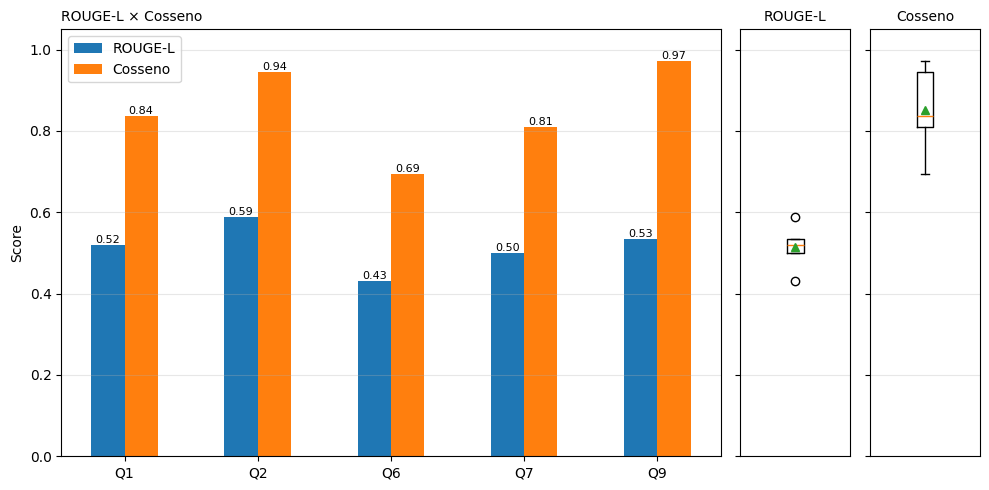

In [48]:
# Análise sobre a distribuição das métricas/KPIS, apenas sobre os resultados CORRETOS

valid      = kpis[kpis["human_review"] == "correto"]
labels     = [f"Q{i+1}" for i in valid.index]
rouge_vals = valid["rougeL"].tolist()
cos_vals   = valid["cosseno"].tolist()

fig, (ax, ax_r, ax_c) = plt.subplots(
    1, 3, figsize=(10, 5), sharey=True,
    gridspec_kw={"width_ratios": [3, 0.5, 0.5]}
)

x = np.arange(len(labels))
w = 0.25

b1 = ax.bar(x - w/2, rouge_vals, w, label="ROUGE-L")
b2 = ax.bar(x + w/2, cos_vals,   w, label="Cosseno")

ax.bar_label(b1, fmt="%.2f", fontsize=8)
ax.bar_label(b2, fmt="%.2f", fontsize=8)
ax.set_xticks(x); ax.set_xticklabels(labels)
ax.set_ylim(0, 1.05)
ax.set_ylabel("Score")
ax.set_title("ROUGE-L × Cosseno", loc="left", fontsize=10)
ax.legend()
ax.grid(axis="y", alpha=0.3)

ax_r.boxplot(rouge_vals, showmeans=True)
ax_r.set_title("ROUGE-L", fontsize=10)
ax_r.set_xticks([])
ax_r.grid(axis="y", alpha=0.3)

ax_c.boxplot(cos_vals, showmeans=True)
ax_c.set_title("Cosseno", fontsize=10)
ax_c.set_xticks([])
ax_c.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

In [49]:
print(f"ROUGE-L médio: {np.mean([r['rougeL'] for r in results_eval]):.4f}")
print(f"Cosseno médio: {np.mean([r['cosseno'] for r in results_eval]):.4f}")

ROUGE-L médio: 0.3333
Cosseno médio: 0.6361


* RAG com filtro por ano

In [50]:
# RAG do item 2.3, porém com o filtro por ano
results_eval_year = []
for pair in EVAL_SET:
    output = rag_filtering_year(pair["pergunta"], k=3)
    y_hat  = output["answer"]
    y_true = pair["resposta_esperada"]

    rougeL = scorer.score(y_true, y_hat)["rougeL"].fmeasure
    cos    = cosseno(y_hat, y_true)

    results_eval_year.append({
        "pergunta"          : pair["pergunta"],
        "fonte"             : pair["fonte"],
        "resposta_gerada"   : y_hat,
        "resposta_esperada" : y_true,
        "contexto"          : output["context"],
        "rougeL"            : round(rougeL, 4),
        "cosseno"           : round(cos, 4)
    })
    time.sleep(0.5)

In [51]:
kpis_year = pd.DataFrame(results_eval_year)
kpis_year

,pergunta,fonte,resposta_gerada,resposta_esperada,contexto,rougeL,cosseno
0,How many respondents participated in the 2022 ...,kaggle_survey_2022.pdf,23.997 respondentes participaram da pesquisa d...,A pesquisa de 2022 teve 23.997 respondentes de...,[page_content='2022 Kaggle Data \nScience & ML...,0.5000,0.8236
1,What are the two most common programming skill...,kaggle_survey_2022.pdf,Python e SQL são as duas habilidades de progra...,As duas habilidades de programação mais comuns...,[page_content='01 Demographics\n02 Programming...,0.5882,0.9442
2,Which cloud-based Jupyter notebook environment...,kaggle_survey_2022.pdf,Colab notebooks são o ambiente de notebook Jup...,O Google Colab é o ambiente de notebook Jupyte...,[page_content='within a web browser? What do y...,0.6667,0.8215
3,"According to the 2022 survey, in which two cou...",kaggle_survey_2022.pdf,"De acordo com o contexto, a resposta é: Índia ...","Segundo a pesquisa de 2022, o número de data s...",[page_content='An increasing number of data sc...,0.4000,0.3951
4,How many people responded to the 2021 Kaggle s...,kaggle_survey_2021.pdf,Mais de 25.000 pessoas responderam ao levantam...,Mais de 25.000 cientistas de dados e engenheir...,[page_content='submitted responses on their ba...,0.4667,0.6703
5,"Which IDE leads among data scientists in 2021,...",kaggle_survey_2021.pdf,"De acordo com o contexto, o IDE que leva entre...",Os IDEs baseados em Jupyter lideram (cerca de ...,[page_content='Kaggle | State of ML & Data...,0.4545,0.6147
6,What were the most commonly used algorithms am...,kaggle_survey_2021.pdf,"De acordo com o contexto, os algoritmos mais c...",Os algoritmos mais usados em 2021 foram regres...,[page_content='where JupyterLab was not yet an...,0.4638,0.8085
7,On how many responses was the 2020 survey base...,kaggle_survey_2020.pdf,Não há informação disponível no contexto sobre...,A pesquisa de 2020 baseou-se em 20.036 membros...,[page_content='Many survey questions were mult...,0.1667,0.4178
8,What was the most popular machine learning too...,kaggle_survey_2020.pdf,A ferramenta de aprendizado de máquina mais po...,O scikit-learn foi a ferramenta de machine lea...,[page_content='Technology\nMore data scientist...,0.4800,0.9553
9,What was the predominant education level among...,kaggle_survey_2020.pdf,Não há informação disponível no contexto sobre...,Mais de 68% dos data scientists em 2020 tinham...,[page_content='Though not included in this cha...,0.3333,0.4056


In [52]:
for i, r in enumerate(results_eval_year, 1):
    print(f"[{i}] ❓ Pergunta: {r['pergunta']}")
    print(f"    💬 Gerada:   {r['resposta_gerada']}")
    print(f"    ✅ Esperada: {r['resposta_esperada']}")
    print(f"    📊 ROUGE-L={r['rougeL']} | cosseno={r['cosseno']}")
    print("-" * 90)

[1] ❓ Pergunta: How many respondents participated in the 2022 Kaggle survey, and from how many countries?
    💬 Gerada:   23.997 respondentes participaram da pesquisa do Kaggle em 2022, originários de 173 países.
    ✅ Esperada: A pesquisa de 2022 teve 23.997 respondentes de 173 países.
    📊 ROUGE-L=0.5 | cosseno=0.8236
------------------------------------------------------------------------------------------
[2] ❓ Pergunta: What are the two most common programming skills among data scientists in 2022?
    💬 Gerada:   Python e SQL são as duas habilidades de programação mais comuns entre cientistas de dados em 2022.
    ✅ Esperada: As duas habilidades de programação mais comuns em 2022 são Python e SQL.
    📊 ROUGE-L=0.5882 | cosseno=0.9442
------------------------------------------------------------------------------------------
[3] ❓ Pergunta: Which cloud-based Jupyter notebook environment is the most popular in 2022?
    💬 Gerada:   Colab notebooks são o ambiente de notebook Jupyter

In [53]:
# Minha revisão sobre as respostas:
HUMAN_REVIEW = {
  1 : "correto",
  2 : "correto",
  3 : "correto",
  4 : "correto",
  5 : "correto",
  6 : "correto",
  7 : "correto",
  8 : "sem_contexto",
  9 : "correto",
  10: "sem_contexto"
}
kpis_year["human_review"] = list(HUMAN_REVIEW.values())

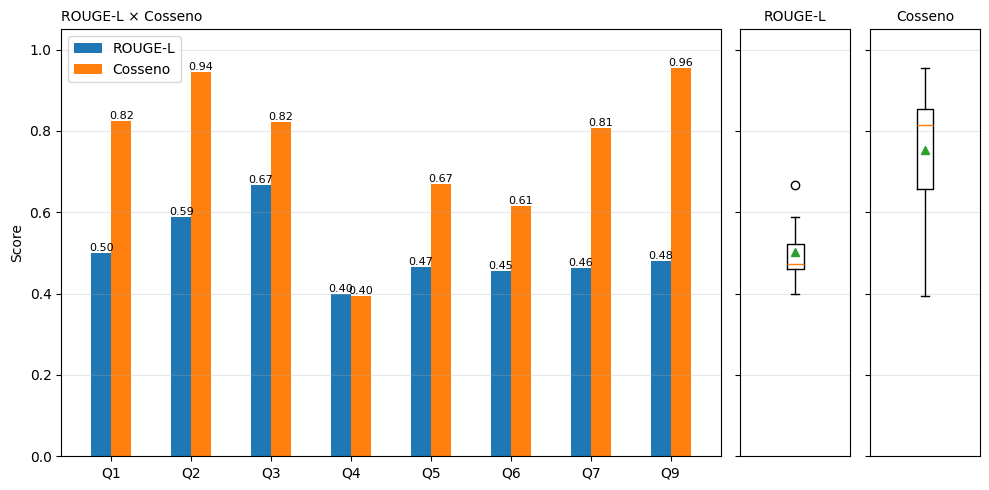

In [54]:
# Análise sobre a distribuição das métricas/KPIS, apenas sobre os resultados CORRETOS

valid      = kpis_year[kpis_year["human_review"] == "correto"]
labels     = [f"Q{i+1}" for i in valid.index]
rouge_vals = valid["rougeL"].tolist()
cos_vals   = valid["cosseno"].tolist()

fig, (ax, ax_r, ax_c) = plt.subplots(
    1, 3, figsize=(10, 5), sharey=True,
    gridspec_kw={"width_ratios": [3, 0.5, 0.5]}
)

x = np.arange(len(labels))
w = 0.25

b1 = ax.bar(x - w/2, rouge_vals, w, label="ROUGE-L")
b2 = ax.bar(x + w/2, cos_vals,   w, label="Cosseno")

ax.bar_label(b1, fmt="%.2f", fontsize=8)
ax.bar_label(b2, fmt="%.2f", fontsize=8)
ax.set_xticks(x); ax.set_xticklabels(labels)
ax.set_ylim(0, 1.05)
ax.set_ylabel("Score")
ax.set_title("ROUGE-L × Cosseno", loc="left", fontsize=10)
ax.legend()
ax.grid(axis="y", alpha=0.3)

ax_r.boxplot(rouge_vals, showmeans=True)
ax_r.set_title("ROUGE-L", fontsize=10)
ax_r.set_xticks([])
ax_r.grid(axis="y", alpha=0.3)

ax_c.boxplot(cos_vals, showmeans=True)
ax_c.set_title("Cosseno", fontsize=10)
ax_c.set_xticks([])
ax_c.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

In [55]:
print(f"ROUGE-L médio: {np.mean([r['rougeL'] for r in results_eval_year]):.4f}")
print(f"Cosseno médio: {np.mean([r['cosseno'] for r in results_eval_year]):.4f}")

ROUGE-L médio: 0.4520
Cosseno médio: 0.6857


### Tarefa 3.3: LLM-as-a-judge

* Selecionado como juiz, `llama-3.3-70b-versatile`
* Cada resposta gerada é avaliada, recebendo **pergunta + resposta + contexto recuperado**
* Uma nota **1–5** (Likert) será atribuída quanto aos critérios: fidelidade, relevância, completude
* Comparação da **distribuição das notas** com o `human_review`

In [62]:
JUDGE_MODEL  = GIC_MODEL # "llama-3.3-70b-versatile" (HTTP 429)

JUDGE_SYSTEM = """
  Você é um avaliador rigoroso de um sistema RAG.

  Avalie a RESPOSTA em relação à PERGUNTA e ao CONTEXTO.

  Dê nota inteira de 1 a 5 para:
  - fidelidade: a resposta é sustentada pelo CONTEXTO?
  - relevancia: responde de fato à PERGUNTA?
  - completude: cobre os pontos principais?

  Onde: 5: totalmente de acordo, 1: totalmente de desacordo.
  Adicione uma justificativa sobre suas avaliações.

  Responda SOMENTE em JSON válido, sem texto adicional e neste formato:
  {
    "fidelidade": <1-5>,
    "relevancia": <1-5>,
    "completude": <1-5>,
    "justificativa": "<1 frase>"
  }
"""

In [63]:
def prompt_judge(question, answer, docs):
    context = "\n\n".join(d.page_content for d in docs)
    return f"PERGUNTA:\n{question}\n\nCONTEXTO RECUPERADO:\n{context}\n\nRESPOSTA GERADA:\n{answer}"

judge_results = []
for i, r in enumerate(results_eval_year, 1):
    p = prompt_judge(r["pergunta"], r["resposta_gerada"], r["contexto"])
    eval, _ = invoke_gemini(gic, p, JUDGE_MODEL, JUDGE_SYSTEM, 0.0, 300, 1.0)
    eval = eval or {}
    judge_results.append({
        "Q"            : i,
        "fidelidade"   : eval.get("fidelidade"),
        "relevancia"   : eval.get("relevancia"),
        "completude"   : eval.get("completude"),
        "justificativa": eval.get("justificativa"),
        "human_review" : HUMAN_REVIEW.get(i, "—")
    })
    # RPM / rate limit...
    time.sleep(0.5)

In [64]:
df_judge = pd.DataFrame(judge_results)
df_judge

,Q,fidelidade,relevancia,completude,justificativa,human_review
0,1,5,5,5,A resposta extraiu corretamente os dados numér...,correto
1,2,5,5,5,A resposta identifica corretamente Python e SQ...,correto
2,3,5,5,5,A resposta responde diretamente à pergunta uti...,correto
3,4,5,5,5,A resposta identifica corretamente os dois paí...,correto
4,5,5,5,5,A resposta utiliza corretamente a informação p...,correto
5,6,5,5,5,A resposta responde precisamente à pergunta ut...,correto
6,7,5,5,4,A resposta reflete com precisão os dados do co...,correto
7,8,5,5,5,O contexto fornecido não contém o número total...,sem_contexto
8,9,5,5,5,A resposta responde precisamente à pergunta ut...,correto
9,10,1,5,1,O contexto afirma explicitamente que 'mais da ...,sem_contexto


In [65]:
print("Médias por critério (1–5):")
print(df_judge[["fidelidade", "relevancia", "completude"]].mean().round(2).to_string())

Médias por critério (1–5):
fidelidade    4.6
relevancia    5.0
completude    4.5


In [66]:
print("Média do juiz por veredito humano:")
df_judge.groupby("human_review")[["fidelidade", "relevancia", "completude"]].mean().round(2)

Média do juiz por veredito humano:


,fidelidade,relevancia,completude
human_review,,,
correto,5.0,5.0,4.88
sem_contexto,3.0,5.0,3.00


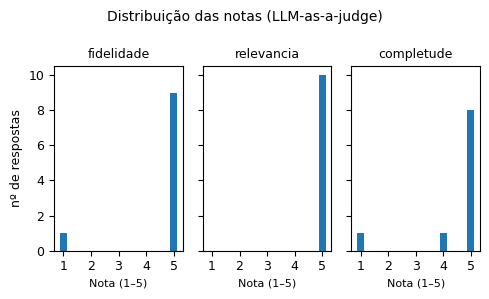

In [67]:
criterios = ["fidelidade", "relevancia", "completude"]
scores = [1, 2, 3, 4, 5]

fig, axes = plt.subplots(1, 3, figsize=(5, 3), sharey=True)

for ax, c in zip(axes, criterios):
    counts = [int((df_judge[c] == s).sum()) for s in scores]
    ax.bar(scores, counts, width=0.25)
    ax.set_title(c, fontsize=9)
    ax.set_xlabel("Nota (1–5)", fontsize=8)
    ax.set_xticks(scores)
    ax.tick_params(labelsize=9)

axes[0].set_ylabel("nº de respostas", fontsize=9)
fig.suptitle("Distribuição das notas (LLM-as-a-judge)", fontsize=10)
plt.tight_layout()
plt.show()

## Entrega

| Item | Detalhe |
|------|---------|
| **Formato** | Arquivo `.ipynb` com todas as células executadas |
| **Nome do arquivo** | `trabalho_final_[seu_nome].ipynb` |
| **Prazo** | Conforme comunicado pelo professor |
| **Plataforma** | Submissão via google classroom |

> Notebooks com células não executadas, sem outputs ou que gerem erros ao rodar serão penalizados.
> A presença de API keys expostas diretamente no código implica desconto de **1 ponto**.
